# Demo 1 · Sampling parameters, seen live

Companion to **Lecture 02 · LLM Fundamentals** (slides 37–50). The lecture describes the pipeline:

> logits over the vocabulary → **temperature** reshapes → **top-k / top-p / min-p** cut the tail → **sample one token** → append, repeat.

Here we turn every knob through the OpenRouter API and look at what comes back.

**Budget note.** Both models are on OpenRouter's free tier (~50 requests/day per key). The notebook makes about **21 calls** in total, and every response is cached to `cache/responses.json`, so re-running a cell costs nothing. Set `FORCE_REFRESH = True` in the setup cell to re-query.

**Why two models?** OpenRouter silently drops any parameter a provider does not support. The primary free model (`MODEL_NAME`, Nemotron) accepts only `temperature`, `top_p`, `seed`, `reasoning`; for `top_k`, `logprobs` and penalties we switch to a second free model (`SECOND_MODEL_NAME`, Ling). The next cells prove that claim instead of asserting it.

## 0 · Setup: keys, clients, helpers

In [2]:
import os, json, time, hashlib, math
from pathlib import Path

from dotenv import load_dotenv
import requests
from openai import OpenAI, RateLimitError

# The .env lives at the repository root, one level above this folder.
load_dotenv(Path("..") / ".env")

API_KEY = os.environ.get("API_KEY", "")
BASE_URL = os.environ.get("BASE_URL", "https://openrouter.ai/api/v1")
MODEL = os.environ.get("MODEL_NAME")          # primary free model
MODEL_2 = os.environ.get("SECOND_MODEL_NAME") # free Ling: supports top_k / logprobs / penalties

assert API_KEY, "API_KEY is empty: copy .env.example to .env and paste your OpenRouter key"
assert MODEL and MODEL_2, "MODEL_NAME / SECOND_MODEL_NAME missing from .env"

# Never print the key. Printing the config *names* is enough to know it loaded.
print("BASE_URL  :", BASE_URL)
print("MODEL     :", MODEL)
print("MODEL_2   :", MODEL_2)
print("API_KEY   : loaded")

BASE_URL  : https://openrouter.ai/api/v1
MODEL     : nvidia/nemotron-3-ultra-550b-a55b:free
MODEL_2   : inclusionai/ling-3.0-flash-vl:free
API_KEY   : loaded


### Which parameters does each model actually accept?

`GET /models` is public (no key, no quota). Each entry carries `supported_parameters`: anything **not** in that list is ignored by OpenRouter, without an error.

In [2]:
KNOBS = ["temperature", "top_p", "top_k", "min_p", "frequency_penalty",
         "presence_penalty", "repetition_penalty", "logprobs", "top_logprobs",
         "seed", "reasoning", "max_tokens"]

catalog = {m["id"]: m for m in requests.get(f"{BASE_URL}/models", timeout=30).json()["data"]}
support = {mid: set(catalog[mid]["supported_parameters"]) for mid in (MODEL, MODEL_2)}

print(f"{'parameter':20s} {MODEL:32s} {MODEL_2}")
print("-" * 90)
for k in KNOBS:
    print(f"{k:20s} {'yes' if k in support[MODEL] else '-':32s} {'yes' if k in support[MODEL_2] else '-'}")

parameter            nvidia/nemotron-3-ultra-550b-a55b:free inclusionai/ling-3.0-flash-vl:free
------------------------------------------------------------------------------------------
temperature          yes                              yes
top_p                yes                              yes
top_k                -                                yes
min_p                -                                -
frequency_penalty    -                                yes
presence_penalty     -                                yes
repetition_penalty   -                                yes
logprobs             -                                yes
top_logprobs         -                                yes
seed                 yes                              yes
reasoning            yes                              yes
max_tokens           yes                              yes


### The helper

One function, `generate(...)`, wraps the OpenAI-compatible client pointed at OpenRouter. It:

* caches every response in `cache/responses.json` (keyed by model + messages + params + a `tag`), so re-running is free;
* returns a plain dict: `text`, `usage`, `finish_reason`, `latency_s`, plus `reasoning` and `logprobs` when the provider sends them;
* sends `reasoning: {"enabled": false}` unless told otherwise. Both free models are *thinking* models by default, and on a first run their reasoning tokens consumed the whole `max_tokens` budget, leaving the visible answer empty. §11 turns reasoning on deliberately;
* counts real API calls in `CALLS_MADE`;
* retries on HTTP 429 with a pause. Free endpoints hit two different limits: OpenRouter's per-minute free quota, and the upstream provider being busy.

`top_k`, `min_p`, `repetition_penalty` and `reasoning` are OpenRouter extensions, not OpenAI parameters, so they travel in `extra_body`.

In [3]:
FORCE_REFRESH = False
CACHE_PATH = Path("cache") / "responses.json"
CACHE_PATH.parent.mkdir(exist_ok=True)
CACHE = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
CALLS_MADE = 0

client = OpenAI(base_url=BASE_URL, api_key=API_KEY)

OPENROUTER_ONLY = {"top_k", "min_p", "repetition_penalty", "reasoning"}   # go via extra_body

# Shortcut for the second model.
LING = {"model": MODEL_2}


class ProviderBusy(Exception):
    """OpenRouter sometimes answers HTTP 200 with an `error` object and no `choices`. Treat like a 429."""


def with_retry(fn, attempts=6, waits=(20, 30, 45, 60, 60)):
    """Free endpoints answer 429 both for our per-minute quota and for upstream load. Back off and retry."""
    for i in range(attempts):
        try:
            return fn()
        except (RateLimitError, ProviderBusy) as e:
            if i == attempts - 1:
                raise
            wait = waits[min(i, len(waits) - 1)]
            print(f"  rate-limited / provider busy, retrying in {wait}s ({i + 1}/{attempts - 1}): {str(e)[:120]}")
            time.sleep(wait)


def _cache_key(model, messages, params, tag):
    blob = json.dumps({"model": model, "messages": messages, "params": params, "tag": tag}, sort_keys=True)
    return hashlib.sha256(blob.encode()).hexdigest()[:16]


def _save_cache():
    CACHE_PATH.write_text(json.dumps(CACHE, indent=1, ensure_ascii=False))


def generate(prompt, model=None, tag="", system=None, **params):
    """Single chat completion with caching. Extra kwargs are sampling parameters."""
    global CALLS_MADE
    model = model or MODEL
    params.setdefault("reasoning", {"enabled": False})   # both free models think by default; §11 turns it on explicitly
    messages = ([{"role": "system", "content": system}] if system else []) + [{"role": "user", "content": prompt}]
    key = _cache_key(model, messages, params, tag)
    if key in CACHE and not FORCE_REFRESH:
        return CACHE[key]

    kwargs = {k: v for k, v in params.items() if k not in OPENROUTER_ONLY}
    extra = {k: v for k, v in params.items() if k in OPENROUTER_ONLY}
    t0 = time.perf_counter()

    def _call():
        global CALLS_MADE
        CALLS_MADE += 1
        d = client.chat.completions.create(model=model, messages=messages, extra_body=extra or None, **kwargs).model_dump()
        if not d.get("choices"):
            err = d.get("error") or {}
            if err.get("code") in (429, 502, 503) or "rate" in str(err).lower():
                raise ProviderBusy(err)
            raise RuntimeError(f"provider returned no choices: {err or d}")
        return d

    d = with_retry(_call)
    latency = time.perf_counter() - t0
    choice = d["choices"][0]
    usage = d.get("usage") or {}
    result = {
        "model": d.get("model", model),
        "params": params,
        "text": choice["message"].get("content") or "",
        "reasoning": choice["message"].get("reasoning"),
        "finish_reason": choice.get("finish_reason"),
        "usage": {
            "prompt_tokens": usage.get("prompt_tokens"),
            "completion_tokens": usage.get("completion_tokens"),
            "reasoning_tokens": (usage.get("completion_tokens_details") or {}).get("reasoning_tokens"),
        },
        "logprobs": (choice.get("logprobs") or {}).get("content"),
        "latency_s": round(latency, 2),
    }
    CACHE[key] = result
    _save_cache()
    return result


def show(*results, labels=None, width=100):
    """Print results one under another with a header line each."""
    for i, r in enumerate(results):
        label = labels[i] if labels else ", ".join(f"{k}={v}" for k, v in r["params"].items()) or "defaults"
        u = r["usage"]
        header = f" {label} | {r['latency_s']}s | out={u['completion_tokens']} tok | finish={r['finish_reason']} "
        print("=" * width)
        print(header.center(width, "="))
        print("=" * width)
        print(r["text"].strip())
        print()

print("cached responses on disk:", len(CACHE))

cached responses on disk: 20


## 1 · One raw HTTP call: the wire format

Before any SDK: the whole API is one `POST` with a JSON body. Everything the SDK does later is sugar over this.

The request carries the key in an `Authorization` header (shown redacted). The response is JSON too: the generated text sits at `choices[0].message.content`, and `usage` tells you what you paid for in tokens.

In [4]:
body = {
    "model": MODEL,
    "messages": [{"role": "user", "content": "In one sentence: what is a token in a language model?"}],
    "temperature": 0.7,
    "max_tokens": 60,
    "reasoning": {"enabled": False},   # OpenRouter extension; both free models think by default
}
headers = {"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"}

print("REQUEST  →", BASE_URL + "/chat/completions")
print(json.dumps({"headers": {"Authorization": "Bearer ****", "Content-Type": "application/json"}, "body": body}, indent=2))

raw_key = _cache_key(body["model"], body["messages"], {"temperature": 0.7, "max_tokens": 60, "reasoning": {"enabled": False}}, "raw-http")
if raw_key in CACHE and not FORCE_REFRESH:
    raw = CACHE[raw_key]["raw"]
else:
    def _post():
        r = requests.post(f"{BASE_URL}/chat/completions", headers=headers, json=body, timeout=60)
        if r.status_code == 429:
            raise RateLimitError(r.text, response=r, body=None)
        return r.json()
    raw = with_retry(_post)
    CALLS_MADE += 1
    CACHE[raw_key] = {"raw": raw, "params": {}, "text": "", "usage": {}, "finish_reason": None, "latency_s": None}
    _save_cache()

print("\nRESPONSE ←")
print(json.dumps(raw, indent=2, ensure_ascii=False))

REQUEST  → https://openrouter.ai/api/v1/chat/completions
{
  "headers": {
    "Authorization": "Bearer ****",
    "Content-Type": "application/json"
  },
  "body": {
    "model": "nvidia/nemotron-3-ultra-550b-a55b:free",
    "messages": [
      {
        "role": "user",
        "content": "In one sentence: what is a token in a language model?"
      }
    ],
    "temperature": 0.7,
    "max_tokens": 60,
    "reasoning": {
      "enabled": false
    }
  }
}

RESPONSE ←
{
  "id": "gen-1789079130-Wy9KvmEe7O64JaYFZj3o",
  "object": "chat.completion",
  "created": 1789079130,
  "model": "nvidia/nemotron-3-ultra-550b-a55b:free",
  "provider": "Nvidia",
  "system_fingerprint": null,
  "service_tier": null,
  "choices": [
    {
      "index": 0,
      "logprobs": null,
      "finish_reason": "stop",
      "native_finish_reason": "stop",
      "message": {
        "role": "assistant",
        "content": "A token is a numerical representation of a chunk of text—ranging from a single character to

**Is anything in that response sensitive?** No. It carries a generation id, the model and provider that served it, token counts, `cost` (0 on the free tier), `is_byok` (whether your own provider key was used), and the text. There is no API key, no account identifier, no header echo. The key travels only in the *request* header, which is why the request print above redacts it and the response print does not need to.

## 2 · Streaming: watch the loop run

With `stream=True` the server sends each token (or small group of tokens) as soon as it is sampled. This is the generation loop from the lecture made visible: **sample → append → repeat**. Nothing is planned ahead; the model has not "decided" the last line when it emits the first.

In [5]:
stream_prompt = "Write a four-line poem about a lighthouse."
stream_key = _cache_key(MODEL, [{"role": "user", "content": stream_prompt}], {"stream": True, "max_tokens": 80}, "stream")

if stream_key in CACHE and not FORCE_REFRESH:
    chunks = CACHE[stream_key]["chunks"]
    for c in chunks:
        print(c, end="", flush=True)
else:
    chunks = []
    stream = with_retry(lambda: client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": stream_prompt}],
        max_tokens=80, temperature=0.7, stream=True,
        extra_body={"reasoning": {"enabled": False}},
    ))
    CALLS_MADE += 1
    for event in stream:
        delta = event.choices[0].delta.content if event.choices else None
        if delta:
            chunks.append(delta)
            print(delta, end="", flush=True)
    CACHE[stream_key] = {"chunks": chunks, "params": {}, "text": "".join(chunks), "usage": {}, "finish_reason": None, "latency_s": None}
    _save_cache()

print(f"\n\n→ arrived in {len(chunks)} chunks; each chunk is one decode step (or a few, batched by the provider).")

A

 steadfast sentinel

 on the shore,


It cuts

 the dark with

...

 peril

ous rocks

 through

 the night.



→ arrived in 18 chunks; each chunk is one decode step (or a few, batched by the provider).


## 3 · `temperature = 0`: identical every time?

Slide 42: *"You set temperature = 0. Do you now get byte-identical output on every run? If not, the sampler is no longer choosing anything, so what is left that could still move?"*

Same prompt, same `seed`, three calls. The `tag` is what makes the cache treat them as three separate requests.

In [6]:
STORY_PROMPT = "Write the opening sentence of a short story about a lighthouse keeper. One sentence only."

runs_t0 = [generate(STORY_PROMPT, temperature=0, seed=42, max_tokens=60, tag=f"t0-run{i}") for i in range(3)]
show(*runs_t0, labels=[f"run {i+1}  (temperature=0, seed=42)" for i in range(3)])

texts = [r["text"].strip() for r in runs_t0]
print("byte-identical across the 3 runs:", len(set(texts)) == 1)

================ run 1  (temperature=0, seed=42) | 6.79s | out=22 tok | finish=stop ================
The beam swept the black water like a blind man’s cane, searching for rocks Elias knew by heart.

=============== run 2  (temperature=0, seed=42) | 20.73s | out=32 tok | finish=stop ================
The beam swept the black water like a metronome counting down the seconds until Elias could finally stop winding the weights and let the dark take its course.

================ run 3  (temperature=0, seed=42) | 6.1s | out=22 tok | finish=stop =================
The beam swept the black water like a blind man’s cane, searching for rocks Elias knew by heart.

byte-identical across the 3 runs: False


Two of the three runs match; one diverges, and it diverges at a single point ("like a **blind man's cane**" vs "like a **metronome**"). Everything before that token was identical, so the sampler was still picking the argmax each step. What changed is the *logits* it was picking from. Possible reasons, roughly in order of likelihood:

* **Floating-point non-determinism.** GPU reductions are not associative; which kernel runs, and in what order it sums, depends on the batch the request landed in. Two candidates with nearly equal logits can swap places on a rounding difference. At a metaphor boundary ("like a ...") many continuations are plausible, so the top two are close and a tiny perturbation flips them.
* **Mixture-of-Experts routing.** The primary model here is a 550B MoE with ~55B active parameters. Which experts a token is routed to can depend on the other requests in the batch (capacity limits, expert parallelism), which changes the computation itself, not just its rounding.
* **Different replica or hardware.** The diverging run took 20 s against 6–7 s for the other two, a hint that it was served by a different instance under different load.
* **`seed` is best effort.** OpenRouter forwards it, but not every provider honours it, and none can honour it across the effects above.

This is slide 42's point: temperature 0 removes the *sampler's* randomness, nothing else. If you need identical outputs, cache them yourself.

## 4 · Temperature: sharp → flat → noise

Same story prompt at `0.7` (the usual default), `1.5` (flat), `2.0` (very flat). Compare with the `temperature=0` run above. Slide 39: temperature never removes a token from the distribution, it only reshapes it; at high values the long tail gets real probability mass, and eventually the sampler picks from it.

In [7]:
runs_temp = [generate(STORY_PROMPT, temperature=t, max_tokens=60) for t in (0.7, 1.5, 2.0)]
show(runs_t0[0], *runs_temp, labels=["temperature=0", "temperature=0.7", "temperature=1.5", "temperature=2.0"])

========================= temperature=0 | 6.79s | out=22 tok | finish=stop =========================
The beam swept the black water like a blind man’s cane, searching for rocks Elias knew by heart.

======================== temperature=0.7 | 3.94s | out=23 tok | finish=stop ========================
The beam swept the black water like a clock hand counting down to a shipwreck he knew was coming.

======================= temperature=1.5 | 10.47s | out=27 tok | finish=stop ========================
Every night, Elias polished the great lens until it swallowed the stars whole, painting the black Atlantic with a liable, liquid gold.

====================== temperature=2.0 | 34.32s | out=60 tok | finish=length =======================
J PalaisERVERowane Bra зе sidस्ट册 յ abdominalujące_equal',

dx有时Christopher Boll.ip際 خاطرحص ka मिल用DOCTYPE iss ambitionaney impactorompta 이어 عاج выбора THI instalaciones푸ручogram rivalry hohe habDeilh Cantonның overthrowokaniculturalground gaining Romanسنple.assi

## 5 · The distribution itself: `logprobs`

So far we only saw the *sampled* token. With `logprobs=True, top_logprobs=10` the provider returns the log-probability of the top candidates at every step. That is the bar chart from slide 39, live.

We ask for a single word, so the first step *is* the interesting one. This uses the second model; the primary model's endpoint drops `logprobs`.

Two things to read carefully in the output:

* **The candidates are subword tokens, not words.** The bars show `to` and `ce`, while the answers read "toast" and "cereal". The chart is the distribution at the **first decode step**; the word is finished on later steps (`to` + `ast`, `ce` + `real`). Note also that `Toast`, ` Toast` (with a leading space) and `to` are three *different* candidates to the model. Slide 51: it never received letters or words, only pieces.
* **The most likely token is not always the sampled one.** At the higher temperature `to` is still on top, but the gap to `ce` has narrowed, and this time `ce` was drawn. That is what sampling means: the top token *usually* wins, not always.

Some providers report logprobs **before** temperature is applied, others **after**. If the two charts look identical, the provider does the former and temperature only changed what was *sampled*, not what was *reported*.

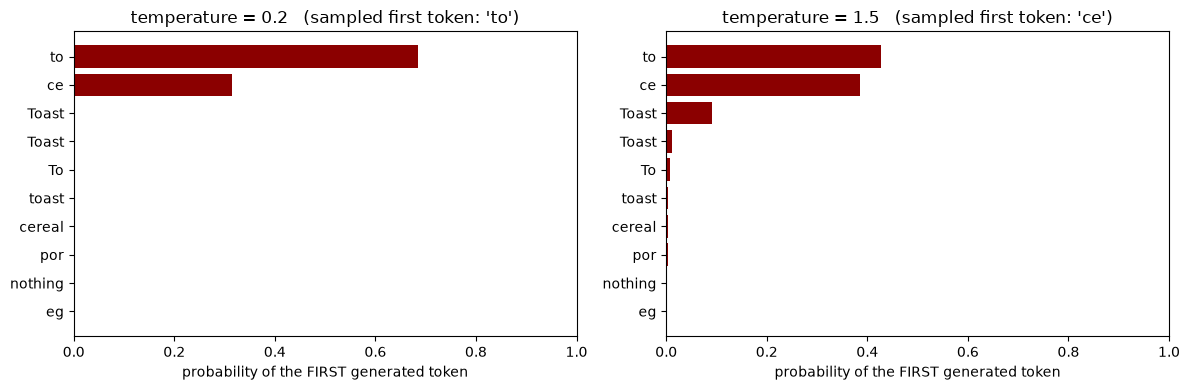

T=0.2: most likely first token='to' p=0.685 | sampled token sequence=['to'] → text='toast'
T=1.5: most likely first token='to' p=0.428 | sampled token sequence=['ce', 'real'] → text='cereal'


In [8]:
import matplotlib.pyplot as plt

DIST_PROMPT = "Complete this sentence with exactly one word and nothing else: 'For breakfast I usually eat'"

dist = {t: generate(DIST_PROMPT, **LING, temperature=t, max_tokens=3, logprobs=True, top_logprobs=10)
        for t in (0.2, 1.5)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, (t, r) in zip(axes, dist.items()):
    if not r["logprobs"]:
        ax.set_title(f"T={t}: provider returned no logprobs")
        continue
    first = r["logprobs"][0]["top_logprobs"]
    toks = [c["token"] for c in first][::-1]
    probs = [math.exp(c["logprob"]) for c in first][::-1]
    ax.barh(toks, probs, color="#8b0000")
    ax.set_xlim(0, 1)
    ax.set_title(f"temperature = {t}   (sampled first token: {r['logprobs'][0]['token']!r})")
    ax.set_xlabel("probability of the FIRST generated token")
plt.tight_layout()
plt.show()

for t, r in dist.items():
    if r["logprobs"]:
        top = r["logprobs"][0]["top_logprobs"]
        seq = [step["token"] for step in r["logprobs"]]
        print(f"T={t}: most likely first token={top[0]['token']!r} p={math.exp(top[0]['logprob']):.3f} | "
              f"sampled token sequence={seq} → text={r['text'].strip()!r}")

## 6 · `top_k`: keep a fixed number of candidates

`top_k=1` is greedy decoding: whatever the temperature, only the single most likely token survives the cut. `top_k=50` keeps fifty, so at `temperature=1.5` the sampler has a real choice.

Per token, we print the sampled token and the top alternatives the model was considering. With `top_k=1` there is never anything to choose between.

In [9]:
def show_alternatives(r, n_tokens=12):
    if not r["logprobs"]:
        print("(no logprobs returned)"); return
    for step in r["logprobs"][:n_tokens]:
        alts = ", ".join(f"{c['token']!r}:{math.exp(c['logprob']):.2f}" for c in step["top_logprobs"][:3])
        print(f"  {step['token']!r:16s} ← {alts}")

runs_topk = {k: generate(STORY_PROMPT, **LING, temperature=1.5, top_k=k, max_tokens=60, logprobs=True, top_logprobs=3)
             for k in (1, 50)}
show(*runs_topk.values(), labels=[f"top_k={k}, temperature=1.5" for k in runs_topk])

for k, r in runs_topk.items():
    print(f"\n--- top_k={k}: sampled token ← top-3 alternatives (first 12 steps)")
    show_alternatives(r)

=================== top_k=1, temperature=1.5 | 0.89s | out=21 tok | finish=stop ====================
The sea had taken everything from Elias except the light he kept burning at the edge of the world.

=================== top_k=50, temperature=1.5 | 1.13s | out=56 tok | finish=stop ===================
Silas hadn't spoken to another human being in seven months, and yet every night, just before the light atop the tower began its slow rotation across the dark, he would find a fresh cup of coffee smoking on the step as if someone were still listening to him talk.


--- top_k=1: sampled token ← top-3 alternatives (first 12 steps)
  'The'            ← 'The':0.65, 'For':0.18, 'Every':0.08
  ' sea'           ← ' sea':0.42, ' old':0.30, ' lighthouse':0.08
  ' had'           ← ' had':0.59, ' kept':0.19, ',':0.16
  ' taken'         ← ' taken':0.86, ' been':0.04, ' tried':0.04
  ' everything'    ← ' everything':0.99, ' his':0.00, ' everyone':0.00
  ' from'          ← ' from':0.98, ' else':0.02, ' b

## 7 · `top_p`: keep the smallest set whose mass adds to *p*

Unlike top-k, the number of surviving tokens adapts: when the model is confident, few tokens cover 0.95 of the mass; when it is unsure, many do. `top_p=0.1` is nearly greedy; `top_p=0.95` is the common default.

The primary model supports `top_p`, so we are back on it. Temperature stays at `1.5` so that the truncation is what differs.

In [10]:
runs_topp = [generate(STORY_PROMPT, temperature=1.5, top_p=p, max_tokens=60) for p in (0.1, 0.95)]
show(*runs_topp, labels=["top_p=0.1, temperature=1.5", "top_p=0.95, temperature=1.5"])

================== top_p=0.1, temperature=1.5 | 8.85s | out=22 tok | finish=stop ===================
The beam swept the black water like a blind man’s cane, searching for rocks Elias knew by heart.

================== top_p=0.95, temperature=1.5 | 7.75s | out=31 tok | finish=stop ==================
The first time the light failed, Elias was drying a teacup, watching the steam curl into the lantern room like a ghost refusing to leave.



## 8 · Combining knobs: the strictest one wins

Slide 40: *"Set one truncation knob, not three... combining them silently makes the strictest one win."*

`temperature=2.0` alone produced noise in §4. Add `top_k=1` and the noise disappears: after the cut there is one candidate left, and no amount of flattening changes which token has the highest logit.

In [11]:
strict = generate(STORY_PROMPT, **LING, temperature=2.0, top_k=1, max_tokens=60)
show(strict, labels=["temperature=2.0 + top_k=1  (Ling)"])

=============== temperature=2.0 + top_k=1  (Ling) | 0.97s | out=35 tok | finish=stop ===============
The old keeper polished the great lens each morning as if it were a sacred relic, though he had long stopped believing the light could truly save anyone from the rocks below.



## 9 · Frequency penalty: fighting repetition, and overdoing it

Slide 41: the frequency penalty lowers a token's score in proportion to how often it has already appeared. We ask for a paragraph that *should* repeat one word. With no penalty the model repeats it freely. With a heavy penalty, every occurrence of "wave" makes the next one less likely, so the model is pushed towards synonyms, then towards words it would not otherwise have chosen. Watch where the second paragraph starts to sound odd: that is the penalty overriding what the model actually wanted to say, the same mechanism that breaks a JSON schema when the penalised token is a key name.

In [12]:
WAVE_PROMPT = "Write a short paragraph (5-6 sentences) about the sea, using the word 'wave' as often as you can."

runs_pen = [generate(WAVE_PROMPT, **LING, temperature=0.7, frequency_penalty=fp, max_tokens=180) for fp in (0.0, 2.0)]
show(*runs_pen, labels=["frequency_penalty=0.0", "frequency_penalty=2.0"])

import re
for r in runs_pen:
    words = re.findall(r"[a-zA-Z']+", r["text"])
    lower = sum(w in ("wave", "waves") for w in words)
    upper = sum(w in ("Wave", "Waves") for w in words)
    print(f"frequency_penalty={r['params']['frequency_penalty']}: 'wave' x{lower}, 'Wave' x{upper}, {len(words)} words total")

===================== frequency_penalty=0.0 | 1.94s | out=96 tok | finish=stop =====================
Standing on the shore, I watched the first wave roll in with a soothing hiss. A second wave followed close behind, leaving a trail of white foam on the sand. Sometimes a single rogue wave would crash much higher, startling seagulls and splashing my ankles. The steady rhythm of each wave calmed my mind as I listened to the ocean’s endless song. I knew that long after I left, every wave would keep moving, just as it always had.

==================== frequency_penalty=2.0 | 1.64s | out=149 tok | finish=stop =====================
Standing on the shore, you can feel the energy of every wave rolling in from the horizon. Each wave carries a story of distant storms and calm skies, shaping the sand as it breaks. Children laugh as they jump over a small wave, while surfers wait patiently for a larger one to ride. The rhythmic crash of each wave against the rocks creates a soothing melody that nev

What to notice in the `2.0` paragraph:

* The first four sentences look normal: the penalty is still small, because "wave" has appeared only a few times.
* From the fifth sentence on, the grammar degrades ("hidden beneath them waiting to surge forward at any moment,.") and the model reaches for substitutes it did not need before: "a larger one", "swell", "every subtle roll".
* The last word is **"Wave!"** with a capital letter. That is a *different token* from "wave", so it carries no penalty yet. The model found a loophole in the token space, which is exactly what you do not want when the penalised token is a JSON key.

The lesson from slide 41 in one line: penalties are blunt, they act on token ids, not on meaning, and past a certain level they degrade the text rather than de-duplicate it. Use them sparingly, and never with structured output.

## 10 · `max_tokens`: the loop is cut, not finished

`max_tokens` is a hard stop on the decode loop. The model does not "wrap up"; it simply is not called again. `finish_reason` tells you which happened: `stop` means the model emitted its end token, `length` means you cut it off.

In [13]:
cut = generate("Explain how a transformer processes a sentence.", temperature=0.7, max_tokens=20)
show(cut, labels=["max_tokens=20"])
print("finish_reason:", cut["finish_reason"], "   completion_tokens:", cut["usage"]["completion_tokens"])

======================= max_tokens=20 | 38.03s | out=20 tok | finish=length ========================
At a high level, a Transformer processes a sentence **all at once (in parallel)** rather

finish_reason: length    completion_tokens: 20


## 11 · Reasoning: the same loop, more of it, up front

Slides 47–49: a reasoning model does not run a different algorithm. It spends tokens on the problem *before* it spends tokens on the answer, and those tokens are billed as output.

Slide 51's example: the model never saw letters, it saw subword pieces, so counting letters is hard for it. Same question with reasoning off and with reasoning effort `high`. Watch three things: the answer, `reasoning_tokens`, and latency.

OpenRouter normalises the knob across providers as `reasoning: {"effort": ...}` (or `{"enabled": false}` to turn it off).

In [14]:
PUZZLE = "How many times does the letter r appear in the word 'strawberry'? Reply with just the number."

r_off = generate(PUZZLE, temperature=0, max_tokens=400, reasoning={"enabled": False})
r_on = generate(PUZZLE, temperature=0, max_tokens=4000, reasoning={"effort": "high"})

for label, r in (("reasoning off", r_off), ("reasoning effort=high", r_on)):
    u = r["usage"]
    print(f"{label:24s} answer={r['text'].strip()!r:8s} completion_tokens={u['completion_tokens']} "
          f"reasoning_tokens={u['reasoning_tokens']} latency={r['latency_s']}s")

if r_on["reasoning"]:
    print("\n--- reasoning trace (first 1200 chars) ---")
    print(r_on["reasoning"][:1200])
else:
    print("\n(provider did not return the reasoning text; the token count above is still the cost of it)")

reasoning off            answer='3'      completion_tokens=2 reasoning_tokens=0 latency=0.92s
reasoning effort=high    answer='3'      completion_tokens=107 reasoning_tokens=79 latency=1.95s

--- reasoning trace (first 1200 chars) ---
The user is asking for the count of the letter 'r' in the word 'strawberry'.
The word is "strawberry".
Let's spell it out: s-t-r-a-w-b-e-r-r-y.
Count the 'r's:
1. st**r**awberry (3rd letter)
2. strawbe**r**ry (8th letter)
3. strawber**r**y (9th letter)
Total count is 3.
The user requested just the number.


## Wrap-up

| knob | what it does | which model here |
|---|---|---|
| `temperature` | reshapes the distribution; never removes a token | both |
| `top_k` | keeps the *k* most likely tokens, fixed count | Ling only |
| `top_p` | keeps the smallest set with total mass *p*, adaptive | both |
| `min_p` | keeps tokens above a threshold scaled by the top token's probability | *not available on any usable free model; on paid endpoints of the same models it is* |
| `frequency_penalty` | pushes down tokens proportionally to how often they appeared | Ling only |
| `max_tokens` | hard stop on the decode loop; check `finish_reason` | both |
| `reasoning` | same loop, extra tokens before the answer, billed as output | both |

**Defaults worth starting from (slide 45):** temperature `0` for tool arguments, extraction, classification; temperature `0.7` with top-p `0.9` for explanation, drafting, brainstorming. Vary one knob at a time.

**If you only have the primary model:** §5, §6, §8 and §9 will run, but the knobs they demonstrate are silently ignored, so the outputs prove nothing. That is the practical lesson: check `supported_parameters` before trusting a parameter.